# Portfolio Allocator Comparison

**Docker image**: `ml4t`

This capstone notebook compares allocation methods on equal footing, using identical
data and backtest protocols to isolate the impact of the allocation choice.
Equal-weight and inverse-volatility baselines run against MVO and HRP on the same signals.

**Learning Objectives**:
- Run controlled comparisons of allocation methods (EW, IV, MVO, HRP)
- Interpret walk-forward backtest results with regime-sliced diagnostics
- Evaluate methods on Sharpe, drawdown, turnover, and stability
- Understand when allocation choice matters vs when signal dominates

**Book Reference**: Chapter 17, Section 17.4 (Defining baseline allocators) and Section 17.7
(Comparing allocator performance)

**Prerequisites**: `02_mean_variance_optimization`, `06_hierarchical_risk_parity`

## 1. Setup and Imports

In [1]:
"""Compare MVO, HRP, inverse volatility, and equal weight on ETF data."""

'Compare MVO, HRP, inverse volatility, and equal weight on ETF data.'

In [2]:
from collections.abc import Callable

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.visualization import create_portfolio_dashboard
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.optimize import minimize
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from case_studies.utils.backtest_loaders import compute_allocator_metrics
from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging, ml4t_palette, show_plotly_with_alt

In [3]:
# Production defaults; Papermill overrides these values for CI testing
MAX_SYMBOLS = 0  # 0 = all
START_DATE = "2016-01-01"
END_DATE = "2024-01-01"
SELECTION_END = "2021-12-31"
HOLDOUT_START = "2022-01-01"
LABEL_HORIZON = 5
ALLOCATION_WINDOW = 252
TURNOVER_INCLUDE_INITIAL = True
MOMENTUM_WINDOWS = [21, 63, 126]
MOVING_AVERAGE_WINDOWS = [21, 63]
VOLATILITY_WINDOW = 21
SIGNAL_LOOKBACK = 252
REBALANCE_FREQ = 21
MAX_SIDE_POSITIONS = 10
COMMISSION_RATE = 0.001
SLIPPAGE_RATE = 0.0005
SEED = 42

In [4]:
set_global_seeds(SEED)

## 2. Data Acquisition

We use a diversified ETF universe spanning equities, fixed income, alternatives, and sectors.

In [5]:
# Full universe using diversified ETFs
US_EQUITIES = ["SPY", "QQQ", "IWM", "VTV", "VUG", "MDY", "IWF", "IWD"]
INTERNATIONAL = ["EFA", "EEM", "VEA", "VWO", "IEFA", "IEMG"]
FIXED_INCOME = ["AGG", "TLT", "LQD", "HYG", "TIP", "SHY", "BND", "IEF", "EMB", "MBB"]
ALTERNATIVES = ["GLD", "SLV", "VNQ", "DBC", "IAU"]
SECTORS = ["XLF", "XLE", "XLK", "XLV", "XLI", "XLU", "XLP", "XLY", "XLB", "XLRE"]
_FULL_UNIVERSE = [*US_EQUITIES, *INTERNATIONAL, *FIXED_INCOME, *ALTERNATIVES, *SECTORS]

In [6]:
# Configuration
UNIVERSE = _FULL_UNIVERSE[:MAX_SYMBOLS] if MAX_SYMBOLS else _FULL_UNIVERSE
BACKTEST_START = "2018-01-01"

print(f"Loading data for {len(UNIVERSE)} ETFs...")

Loading data for 39 ETFs...


### What the signal settings decide

The three feature windows are calendar spans in trading sessions: roughly a month, a quarter and
half a year. Using all three lets the model separate a move that has just started from one that
has been running, which a single window cannot do. The volatility window matches the shortest of
them, so the risk estimate is measured over the same span as the fastest signal.

`SIGNAL_LOOKBACK` is how much history each rebalance's model is fitted on: one trading year, so
the fit sees a full seasonal cycle and still forgets a regime four years gone. `REBALANCE_FREQ`
of 21 sessions rebalances monthly, which is what keeps turnover in a range the transaction-cost
comparison later in the chapter can absorb.

`MAX_SIDE_POSITIONS` caps each side of the long-short book. It is a ceiling rather than the
count: the code below also refuses to put more than a quarter of the loaded universe on either
side, because a long book and a short book that between them name more than half the assets are
not selecting anything.

### Load ETF Price Panel

This helper enforces a consistent data source and panel shape across all allocation methods.

In [7]:
def fetch_etf_data(symbols: list[str], start: str, end: str) -> tuple[pd.DataFrame, pl.DataFrame]:
    """Load a modeling panel and canonical OHLCV bars from the ETF dataset."""
    etf_data = load_etfs()
    etf_filtered = etf_data.filter(
        (pl.col("symbol").is_in(symbols))
        & (pl.col("timestamp") >= pl.lit(start).str.to_date())
        & (pl.col("timestamp") <= pl.lit(end).str.to_date())
    )

    bars = (
        etf_filtered.select(["timestamp", "symbol", "open", "high", "low", "close", "volume"])
        .drop_nulls()
        .sort(["timestamp", "symbol"])
    )
    close_prices = (
        etf_filtered.select(["timestamp", "symbol", "close"])
        .pivot(on="symbol", index="timestamp", values="close")
        .sort("timestamp")
        .to_pandas()
        .set_index("timestamp")
        .ffill()
        .dropna()
    )
    return close_prices, bars


close_prices, etf_bars = fetch_etf_data(UNIVERSE, START_DATE, END_DATE)
returns = close_prices.pct_change().dropna()
print(f"Loaded {len(returns):,} days for {close_prices.shape[1]} ETFs")

loaded_symbols = close_prices.columns.tolist()
missing_symbols = sorted(set(UNIVERSE) - set(loaded_symbols))
coverage = (
    etf_bars.group_by("symbol")
    .agg(
        pl.len().alias("observations"),
        pl.col("timestamp").min().alias("first_timestamp"),
        pl.col("timestamp").max().alias("last_timestamp"),
    )
    .sort("symbol")
)
print(f"Requested symbols: {len(UNIVERSE)}; complete-panel symbols: {len(loaded_symbols)}")
print(f"Missing from the complete panel: {missing_symbols or 'none'}")
coverage

Loaded 2,011 days for 36 ETFs
Requested symbols: 39; complete-panel symbols: 36
Missing from the complete panel: ['IWD', 'IWF', 'MBB']


symbol,observations,first_timestamp,last_timestamp
str,u32,date,date
"""AGG""",2012,2016-01-04,2023-12-29
"""BND""",2012,2016-01-04,2023-12-29
"""DBC""",2012,2016-01-04,2023-12-29
"""EEM""",2012,2016-01-04,2023-12-29
"""EFA""",2012,2016-01-04,2023-12-29
…,…,…,…
"""XLP""",2012,2016-01-04,2023-12-29
"""XLRE""",2012,2016-01-04,2023-12-29
"""XLU""",2012,2016-01-04,2023-12-29


**Universe limitation**: This is a fixed current teaching list applied historically, not a
point-in-time ETF membership file. The coverage table makes missing symbols and inception dates
visible, but the comparison remains subject to survivorship and availability bias.

In [8]:
FEATURE_CONFIG = {
    "momentum": MOMENTUM_WINDOWS,
    "moving_average": MOVING_AVERAGE_WINDOWS,
    "volatility": VOLATILITY_WINDOW,
}
FEATURE_SUFFIXES = [
    *(f"_mom_{window}d" for window in FEATURE_CONFIG["momentum"]),
    *(f"_ma_dist_{window}d" for window in FEATURE_CONFIG["moving_average"]),
    f"_vol_{FEATURE_CONFIG['volatility']}d",
]
print(f"Feature windows: {FEATURE_CONFIG}")

Feature windows: {'momentum': [21, 63, 126], 'moving_average': [21, 63], 'volatility': 21}


## 3. Generate a Common ETF Signal

We use Ridge regression to predict forward returns and select the top/bottom ETFs.

In [9]:
def compute_features(prices_df: pd.DataFrame) -> pd.DataFrame:
    """Compute predictive features."""
    feature_columns = {}
    momentum_windows = FEATURE_CONFIG["momentum"]
    moving_average_windows = FEATURE_CONFIG["moving_average"]
    volatility_window = FEATURE_CONFIG["volatility"]

    for symbol in prices_df.columns:
        close = prices_df[symbol]

        # Momentum
        for window in momentum_windows:
            feature_columns[f"{symbol}_mom_{window}d"] = close.pct_change(window)

        # Mean reversion
        for window in moving_average_windows:
            feature_columns[f"{symbol}_ma_dist_{window}d"] = (
                close / close.rolling(window).mean() - 1
            )

        # Volatility
        feature_columns[f"{symbol}_vol_{volatility_window}d"] = (
            close.pct_change().rolling(volatility_window).std()
        )

    return pd.DataFrame(feature_columns, index=prices_df.index).dropna()

### Ridge Signal Generation

Signals are re-estimated on each rebalance date using rolling cross-sectional samples. The target
is the cumulative return from close `t` through close `t+5`. A row enters a fit only after its
label end date has been observed, so the five-observation horizon is purged at every rebalance.

#### Feature Row Helper

In [10]:
def get_feature_row(features_df, symbol, date):
    """Fetch one symbol's feature vector for a given date."""
    feature_cols = [f"{symbol}{suffix}" for suffix in FEATURE_SUFFIXES]
    if not all(col in features_df.columns for col in feature_cols):
        return None
    row = features_df.loc[date, feature_cols].values
    return row if len(row) == len(FEATURE_SUFFIXES) else None

#### Rolling Sample Builder

In [11]:
def build_training_samples(
    features_df,
    forward_returns,
    symbols,
    dates,
    train_start,
    train_end,
    horizon,
    label_cutoff,
):
    """Build cross-sectional rolling samples for one rebalance step."""
    x_train, y_train = [], []
    for t in range(train_start, train_end):
        target_date = dates[t + horizon] if t + horizon < len(dates) else None
        if target_date is None or target_date > label_cutoff:
            continue
        for symbol in symbols:
            features = get_feature_row(features_df, symbol, dates[t])
            if features is None:
                continue
            target = (
                forward_returns.loc[dates[t], symbol]
                if symbol in forward_returns.columns
                else np.nan
            )
            if not np.isnan(features).any() and not np.isnan(target):
                x_train.append(features)
                y_train.append(target)
    return np.array(x_train), np.array(y_train)

#### Cross-Section Predictor

In [12]:
def predict_cross_section(features_df, symbols, signal_date, scaler, model):
    """Generate per-symbol predictions for one signal date."""
    predictions = {}
    for symbol in symbols:
        features = get_feature_row(features_df, symbol, signal_date)
        if features is None or np.isnan(features).any():
            continue
        features_scaled = scaler.transform(features.reshape(1, -1))
        predictions[symbol] = model.predict(features_scaled)[0]
    return predictions

#### Ridge Fit Helper

In [13]:
def fit_ridge_model(x_train, y_train):
    """Fit one cross-sectional Ridge model and return scaler + model."""
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    model = Ridge(alpha=1.0, random_state=SEED)
    model.fit(x_train_scaled, y_train)
    return scaler, model

#### Signal Row Assembler

In [14]:
def append_signal_rows(
    all_signals, symbols, signal_date, predictions, long_stocks, short_stocks, top_n, bottom_n
):
    """Append one rebalance date's signal rows."""
    for symbol in symbols:
        weight = 0.0
        if symbol in long_stocks:
            weight = 1.0 / top_n
        elif symbol in short_stocks:
            weight = -1.0 / bottom_n
        all_signals.append(
            {
                "timestamp": signal_date,
                "symbol": symbol,
                "prediction": predictions.get(symbol, np.nan),
                "ml_signal": weight,
            }
        )

#### Rebalance Step Helper

Process one rebalance date: train model, predict, select long/short, and record signals.

In [15]:
def _process_rebalance_step(
    features_df,
    forward_returns,
    symbols,
    dates,
    i,
    lookback,
    horizon,
    top_n,
    bottom_n,
    all_signals,
):
    """Train, predict, and record signals for one rebalance date."""
    train_start = max(0, i - lookback)
    x_train, y_train = build_training_samples(
        features_df=features_df,
        forward_returns=forward_returns,
        symbols=symbols,
        dates=dates,
        train_start=train_start,
        train_end=i,
        horizon=horizon,
        label_cutoff=dates[i],
    )
    if len(x_train) < 100:
        return
    scaler, model = fit_ridge_model(x_train, y_train)
    predictions = predict_cross_section(features_df, symbols, dates[i], scaler, model)
    effective_n = min(top_n, bottom_n, max(1, len(predictions) // 2))
    if effective_n == 0:
        return
    pred_series = pd.Series(predictions).sort_values(ascending=False)
    append_signal_rows(
        all_signals,
        symbols,
        dates[i],
        predictions,
        pred_series.head(effective_n).index.tolist(),
        pred_series.tail(effective_n).index.tolist(),
        effective_n,
        effective_n,
    )

#### Walk-Forward Signal Loop

In [16]:
def generate_ml_signals(
    prices: pd.DataFrame,
    lookback: int = 252,
    horizon: int = LABEL_HORIZON,
    top_n: int = 10,
    bottom_n: int = 10,
    rebalance_freq: int = 21,
) -> pd.DataFrame:
    """Generate long/short signal weights using walk-forward Ridge regression."""
    forward_returns = prices.pct_change(horizon).shift(-horizon)
    symbols = prices.columns.tolist()
    features_df = compute_features(prices)
    all_signals = []
    dates = features_df.index.tolist()

    for i in range(lookback, len(dates) - horizon, rebalance_freq):
        if dates[i] < pd.Timestamp(BACKTEST_START):
            continue
        _process_rebalance_step(
            features_df,
            forward_returns,
            symbols,
            dates,
            i,
            lookback,
            horizon,
            top_n,
            bottom_n,
            all_signals,
        )
    return pd.DataFrame(all_signals)

In [17]:
print("Generating ML signals (this may take a minute)...")
max_side = max(1, close_prices.shape[1] // 4)
TOP_N = BOTTOM_N = min(MAX_SIDE_POSITIONS, max_side)
print(
    f"Fitting on {SIGNAL_LOOKBACK} sessions of history, rebalancing every {REBALANCE_FREQ}; "
    f"each side holds {TOP_N} of the {close_prices.shape[1]} funds in the panel "
    f"(the {MAX_SIDE_POSITIONS}-position ceiling, or a quarter of the universe, whichever binds)."
)

ml_signals = generate_ml_signals(
    close_prices,
    lookback=SIGNAL_LOOKBACK,
    top_n=TOP_N,
    bottom_n=BOTTOM_N,
    rebalance_freq=REBALANCE_FREQ,
)
print(f"Generated {len(ml_signals):,} signal records")

if len(ml_signals) == 0:
    raise ValueError(
        "No ML signals generated from the available ETF panel.\n"
        f"Observations: {len(close_prices)}, assets: {close_prices.shape[1]}, "
        f"feature windows: {FEATURE_CONFIG}, lookback: {SIGNAL_LOOKBACK}.\n"
        "This notebook requires enough history to estimate features and fit the walk-forward "
        "cross-sectional ridge model."
    )

print(f"Signal dates: {ml_signals['timestamp'].nunique()}")

Generating ML signals (this may take a minute)...
Fitting on 252 sessions of history, rebalancing every 21; each side holds 9 of the 36 funds in the panel (the 10-position ceiling, or a quarter of the universe, whichever binds).


Generated 2,592 signal records
Signal dates: 72


## 4. Portfolio Allocation Methods

### Equal Weight

In [18]:
def equal_weight_allocation(selected: list[str], n_assets: int) -> dict[str, float]:
    """Equal weight among selected assets."""
    weight = 1.0 / len(selected) if selected else 0.0
    return dict.fromkeys(selected, weight)

### Inverse Volatility

In [19]:
def inverse_vol_allocation(
    returns: pd.DataFrame,
    selected: list[str],
    window: int = 63,
) -> dict[str, float]:
    """Inverse volatility weighting."""
    vols = returns[selected].iloc[-window:].std()
    inv_vols = 1 / vols
    inv_vols = inv_vols.replace([np.inf, -np.inf], 0).fillna(0)
    total = inv_vols.sum()
    if total > 0:
        weights = inv_vols / total
    else:
        weights = pd.Series(1 / len(selected), index=selected)
    return weights.to_dict()

### Minimum-Variance (Ledoit-Wolf)

In [20]:
def mvo_lw_allocation(
    returns: pd.DataFrame,
    selected: list[str],
    window: int = 252,
) -> dict[str, float]:
    """Minimum variance with Ledoit-Wolf shrinkage."""
    subset_returns = returns[selected].iloc[-window:].dropna(axis=1, how="any")

    if len(subset_returns.columns) < 2:
        return equal_weight_allocation(selected, len(selected))

    # Fit Ledoit-Wolf
    lw = LedoitWolf().fit(subset_returns)
    cov_shrunk = lw.covariance_

    n_assets = len(subset_returns.columns)
    initial_weights = np.full(n_assets, 1.0 / n_assets)
    result = minimize(
        fun=lambda weights: float(weights @ cov_shrunk @ weights),
        x0=initial_weights,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n_assets,
        constraints=[{"type": "eq", "fun": lambda weights: float(weights.sum() - 1.0)}],
        options={"ftol": 1e-12, "maxiter": 1_000},
    )
    if not result.success:
        raise RuntimeError(f"Long-only minimum-variance solve failed: {result.message}")

    weights = np.asarray(result.x, dtype=float)
    if (
        not np.isfinite(weights).all()
        or abs(weights.sum() - 1.0) > 1e-8
        or weights.min() < -1e-8
        or weights.max() > 1.0 + 1e-8
    ):
        raise RuntimeError("Long-only minimum-variance solve returned infeasible weights")
    weights = np.clip(weights, 0.0, 1.0)
    weights /= weights.sum()
    return dict(zip(subset_returns.columns, weights, strict=False))

### Hierarchical Risk Parity (HRP)

HRP uses hierarchical clustering on the correlation matrix to group similar assets,
then allocates via recursive bisection. We split the implementation into a cluster
variance helper and the main allocation function.

In [21]:
def _cluster_variance(cov: np.ndarray, indices: list[int]) -> float:
    """Inverse-variance-weighted portfolio variance for a cluster of assets."""
    if len(indices) == 1:
        return cov[indices[0], indices[0]]
    c = cov[np.ix_(indices, indices)]
    ivp = 1 / np.diag(c)
    ivp /= ivp.sum()
    return np.dot(ivp, np.dot(c, ivp))

#### Recursive Bisection Helper

In [22]:
def _recursive_bisect(cov: np.ndarray, sorted_idx: list[int]) -> np.ndarray:
    """Allocate weights via recursive bisection on clustered covariance matrix."""
    n = len(sorted_idx)
    weights = np.ones(n)
    clusters = [sorted_idx]
    while clusters:
        new_clusters = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue
            mid = len(cluster) // 2
            left, right = cluster[:mid], cluster[mid:]
            left_var = _cluster_variance(cov, left)
            right_var = _cluster_variance(cov, right)
            alpha = 1 - left_var / (left_var + right_var) if (left_var + right_var) > 0 else 0.5
            for i in left:
                weights[sorted_idx.index(i)] *= alpha
            for i in right:
                weights[sorted_idx.index(i)] *= 1 - alpha
            if len(left) > 1:
                new_clusters.append(left)
            if len(right) > 1:
                new_clusters.append(right)
        clusters = new_clusters
    final_weights = np.zeros(n)
    for i, orig_idx in enumerate(sorted_idx):
        final_weights[orig_idx] = weights[i]
    return final_weights / final_weights.sum()

#### HRP Allocation Function

In [23]:
def hrp_allocation(
    returns: pd.DataFrame,
    selected: list[str],
    window: int = 252,
) -> dict[str, float]:
    """Hierarchical Risk Parity allocation."""
    subset_returns = returns[selected].iloc[-window:].dropna(axis=1, how="any")
    if len(subset_returns.columns) < 2:
        return equal_weight_allocation(selected, len(selected))

    # Correlation distance and clustering
    corr = subset_returns.corr().values
    dist = np.sqrt(np.clip(0.5 * (1 - corr), 0.0, 1.0))
    link = linkage(squareform(dist, checks=False), method="ward")
    sorted_idx = list(leaves_list(link))

    # Recursive bisection
    cov = subset_returns.cov().values
    final_weights = _recursive_bisect(cov, sorted_idx)
    return dict(zip(subset_returns.columns, final_weights, strict=False))

## 5. Backtest Engine

### Backtest Result Container

Each backtest returns a plain dict with returns, dates, cumulative return,
turnover, positions, and a `metrics` sub-dict. Annualization assumes 252
trading days per year.

### Walk-Forward Backtest Helpers

Each method receives the same signal schedule and return panel so performance differences
can be attributed to allocation, not data leakage or execution timing.

In [24]:
def _compute_signal_weights(
    signals_df: pd.DataFrame,
    returns_df: pd.DataFrame,
    signal_date,
    allocation_fn: Callable,
    window: int,
) -> dict[str, float]:
    """Compute combined long/short weights for one signal date."""
    date_signals = signals_df[signals_df["timestamp"] == signal_date]
    long_stocks = date_signals[date_signals["ml_signal"] > 0]["symbol"].tolist()
    short_stocks = date_signals[date_signals["ml_signal"] < 0]["symbol"].tolist()
    available_returns = returns_df.loc[:signal_date]

    long_weights = allocation_fn(available_returns, long_stocks, window) if long_stocks else {}
    if short_stocks:
        short_weights = allocation_fn(available_returns, short_stocks, window)
        short_weights = {k: -v for k, v in short_weights.items()}
    else:
        short_weights = {}
    return {**long_weights, **short_weights}

#### Result Packaging Helper

Convert walk-forward positions into the summary metrics used throughout the controlled
comparison. Turnover comes from dense transitions over the union of current and prior symbols,
so complete exits remain visible.

In [25]:
def compute_rebalance_turnover(
    weights: dict[str, float], previous_weights: dict[str, float]
) -> float:
    """Compute half-turnover across the union of current and prior holdings."""
    symbols = set(weights) | set(previous_weights)
    return float(
        0.5
        * sum(
            abs(weights.get(symbol, 0.0) - previous_weights.get(symbol, 0.0)) for symbol in symbols
        )
    )


def average_rebalance_turnover(
    turnover_list: list[float], include_initial: bool = TURNOVER_INCLUDE_INITIAL
) -> float:
    """Average per-rebalance half-turnover, optionally excluding the initial allocation."""
    values = np.asarray(turnover_list, dtype=float)
    if not include_initial:
        values = values[1:]
    return float(values.mean()) if values.size else 0.0


def _build_backtest_result(
    dates_list: list[pd.Timestamp],
    portfolio_returns: list[float],
    turnover_list: list[float],
    positions_list: list[dict[str, float]],
) -> dict:
    """Package returns, positions, and metrics into a dict."""
    returns_arr = np.asarray(portfolio_returns, dtype=float)
    metrics = compute_allocator_metrics(
        pl.Series("returns", returns_arr),
        ann_factor=np.sqrt(252),
    )
    metrics["avg_turnover"] = average_rebalance_turnover(turnover_list)
    annual_vol = float(np.std(returns_arr, ddof=1) * np.sqrt(252)) if len(returns_arr) > 1 else 0.0
    return {
        # datetime64 rather than a list of pandas Timestamps: the static-image writer
        # that renders each figure's PNG cannot serialize a Timestamp.
        "dates": np.asarray(dates_list, dtype="datetime64[ns]"),
        "returns": returns_arr,
        "cumulative_return": np.cumprod(1 + returns_arr),
        "turnover": np.asarray(turnover_list, dtype=float),
        "positions": positions_list,
        "metrics": metrics,
        "annual_vol": annual_vol,
    }

#### Backtest Loop

In [26]:
def run_backtest(
    returns_df: pd.DataFrame,
    signals_df: pd.DataFrame,
    allocation_fn: Callable,
    allocation_name: str,
    window: int = ALLOCATION_WINDOW,
) -> dict:
    """Run walk-forward backtest for one allocation method."""
    signal_dates = sorted(signals_df["timestamp"].unique())
    portfolio_returns, turnover_list, positions_list, dates_list = [], [], [], []
    prev_weights: dict[str, float] = {}

    terminal_date = returns_df.index.max()
    for i, signal_date in enumerate(signal_dates):
        weights = _compute_signal_weights(
            signals_df, returns_df, signal_date, allocation_fn, window
        )
        next_signal_date = signal_dates[i + 1] if i + 1 < len(signal_dates) else terminal_date
        date_mask = (returns_df.index > signal_date) & (returns_df.index <= next_signal_date)
        period_dates = returns_df.index[date_mask]
        for date in period_dates:
            daily_return = sum(
                weights.get(s, 0) * returns_df.loc[date, s]
                for s in returns_df.columns
                if s in weights and not np.isnan(returns_df.loc[date, s])
            )
            portfolio_returns.append(daily_return)
            dates_list.append(date)
            positions_list.append(weights.copy())

        turnover_list.append(compute_rebalance_turnover(weights, prev_weights))
        prev_weights = weights

    return _build_backtest_result(
        dates_list,
        portfolio_returns,
        turnover_list,
        positions_list,
    )

## 6. Run the Allocator Comparison

The selection region ends before 2022. It chooses one allocator exactly once. The later holdout
remains untouched by that choice; all four holdout rows are descriptive diagnostics, and their
ordering does not feed another selection decision.

In [27]:
def slice_signals(
    signals_df: pd.DataFrame,
    start: str | None = None,
    end: str | None = None,
) -> pd.DataFrame:
    """Select signal rows inside an inclusive chronological interval."""
    timestamps = pd.to_datetime(signals_df["timestamp"])
    mask = pd.Series(True, index=signals_df.index)
    if start is not None:
        mask &= timestamps >= pd.Timestamp(start)
    if end is not None:
        mask &= timestamps <= pd.Timestamp(end)
    return signals_df.loc[mask].copy()

In [28]:
# Define allocation methods
allocation_methods = {
    "Equal Weight": lambda ret, sel, win: equal_weight_allocation(sel, len(sel)),
    "Inverse Volatility": inverse_vol_allocation,
    "MVO (Ledoit-Wolf)": mvo_lw_allocation,
    "HRP": hrp_allocation,
}

# Freeze the chronological boundary before evaluating either region.
selection_signals = slice_signals(ml_signals, end=SELECTION_END)
holdout_signals = slice_signals(ml_signals, start=HOLDOUT_START)
if selection_signals.empty or holdout_signals.empty:
    raise ValueError("Selection and holdout regions must both contain signal dates")

print("Running the pre-holdout selection comparison...")
selection_results = {}
for name, fn in allocation_methods.items():
    print(f"  {name}...")
    selection_results[name] = run_backtest(returns, selection_signals, fn, name)

print("Running the holdout diagnostics...")
results = {}
for name, fn in allocation_methods.items():
    print(f"  {name}...")
    results[name] = run_backtest(returns, holdout_signals, fn, name)

print("Both regions complete.")

portfolio_analyses = {
    name: PortfolioAnalysis(returns=result["returns"], dates=result["dates"], periods_per_year=252)
    for name, result in results.items()
}

Running the pre-holdout selection comparison...
  Equal Weight...


  Inverse Volatility...


  MVO (Ledoit-Wolf)...


  HRP...


Running the holdout diagnostics...
  Equal Weight...
  Inverse Volatility...


  MVO (Ledoit-Wolf)...


  HRP...
Both regions complete.


## 7. Performance Comparison

In [29]:
def annualized_sharpe_se(sharpe: float, n_observations: int, periods_per_year: int = 252) -> float:
    """Approximate IID standard error of an annualized Sharpe ratio."""
    if n_observations <= 0:
        return np.nan
    return float(np.sqrt((periods_per_year + 0.5 * sharpe**2) / n_observations))


def build_comparison_table(period_results: dict[str, dict]) -> pd.DataFrame:
    """Summarize one frozen evaluation region without selecting on it."""
    rows = []
    for name, result in period_results.items():
        metrics = result["metrics"]
        sharpe = float(metrics.get("sharpe", 0.0))
        rows.append(
            {
                "Method": name,
                "Total Return": metrics.get("total_return", 0.0),
                "Annual Return": metrics.get("annual_return", 0.0),
                "Annual Vol": result["annual_vol"],
                "Sharpe Ratio": sharpe,
                "Sharpe SE (IID)": annualized_sharpe_se(sharpe, len(result["returns"])),
                "Max Drawdown": metrics.get("max_drawdown", 0.0),
                "Calmar Ratio": metrics.get("calmar", 0.0),
                "Avg Turnover": metrics.get("avg_turnover", 0.0),
            }
        )
    return pd.DataFrame(rows).sort_values("Sharpe Ratio", ascending=False)


selection_comparison_df = build_comparison_table(selection_results)
selected_method = str(selection_comparison_df.iloc[0]["Method"])
comparison_df = build_comparison_table(results)
comparison_df.insert(1, "Selected pre-holdout", comparison_df["Method"] == selected_method)

comparison_df

,Method,Selected pre-holdout,Total Return,Annual Return,Annual Vol,Sharpe Ratio,Sharpe SE (IID),Max Drawdown,Calmar Ratio,Avg Turnover
2,MVO (Ledoit-Wolf),True,0.135631,0.066339,0.148273,0.5070,0.710822,-0.191726,0.3460,1.484327
3,HRP,False,0.080113,0.039686,0.160018,0.3229,0.710714,-0.203544,0.1950,1.244424
1,Inverse Volatility,False,0.047973,0.023946,0.161539,0.2269,0.710677,-0.191665,0.1249,1.103146
0,Equal Weight,False,0.008931,0.004500,0.160494,0.1078,0.710649,-0.195871,0.0230,0.976852


**Reading the table**: The marker identifies the allocator chosen on pre-2022 data. The holdout
ordering is shown to diagnose generalization, not to select a replacement. Avg Turnover is the
mean per-rebalance half-turnover, $0.5\sum_i|w_{i,t}-w_{i,t-1}|$, over the union of current and
prior ETFs. It includes the initial allocation from cash; a switches-only convention would omit
the first observation. These four rows remain gross of explicit commission and slippage.

The turnover column is the one to read carefully, because it measures two things at once and
the table does not separate them. Every rebalance replaces the selected set with whatever the
ridge signal now ranks first, and each allocator then sizes what it holds. Both contribute.

It is tempting to treat the equal-weight row as the selection's share and the excess as the
allocator's, and that does not hold: what a replacement costs depends on the weights being
replaced. Dropping a name held at a fifth for another held at a fifth is a fifth of
half-turnover; dropping a name held at one percent for another at one percent is one percent.
A concentrated allocator therefore has a different selection cost from equal weight's, not the
same one plus a margin. Equal weight is a benchmark for what this rebalance schedule costs a
book that makes no sizing decision, and separating the two shares for any other row would take
turnover computed twice - once over the names entering and leaving, once over the weight
changes among the names retained.

In [30]:
# Same numbers, formatted for readability
comparison_df.style.format(
    {
        "Total Return": "{:.1%}",
        "Annual Return": "{:.1%}",
        "Annual Vol": "{:.1%}",
        "Sharpe Ratio": "{:.3f}",
        "Sharpe SE (IID)": "{:.3f}",
        "Max Drawdown": "{:.1%}",
        "Calmar Ratio": "{:.3f}",
        "Avg Turnover": "{:.1%}",
    }
).hide(axis="index")

Method,Selected pre-holdout,Total Return,Annual Return,Annual Vol,Sharpe Ratio,Sharpe SE (IID),Max Drawdown,Calmar Ratio,Avg Turnover
MVO (Ledoit-Wolf),True,13.6%,6.6%,14.8%,0.507,0.711,-19.2%,0.346,148.4%
HRP,False,8.0%,4.0%,16.0%,0.323,0.711,-20.4%,0.195,124.4%
Inverse Volatility,False,4.8%,2.4%,16.2%,0.227,0.711,-19.2%,0.125,110.3%
Equal Weight,False,0.9%,0.4%,16.0%,0.108,0.711,-19.6%,0.023,97.7%


**Trading implication**: an improvement in Sharpe has to be weighed against the turnover bought
with it, and this table reports that turnover gross of any cost. Chapter 18 prices it.

### Practitioner Interpretation

In [31]:
selected_holdout_row = comparison_df.loc[comparison_df["Method"] == selected_method].iloc[0]
selected_ci_half_width = 1.96 * float(selected_holdout_row["Sharpe SE (IID)"])
display(
    Markdown(
        f"The pre-holdout choice is **{selected_method}**. Its holdout Sharpe is "
        f"**{selected_holdout_row['Sharpe Ratio']:.3f}**, with an approximate IID 95% "
        f"half-width of **{selected_ci_half_width:.3f}**. The interval is a scale check, not a "
        "multiple-comparison adjustment, so drawdown and turnover remain essential diagnostics."
    )
)

The pre-holdout choice is **MVO (Ledoit-Wolf)**. Its holdout Sharpe is **0.507**, with an approximate IID 95% half-width of **1.393**. The interval is a scale check, not a multiple-comparison adjustment, so drawdown and turnover remain essential diagnostics.

## 8. Equity Curves

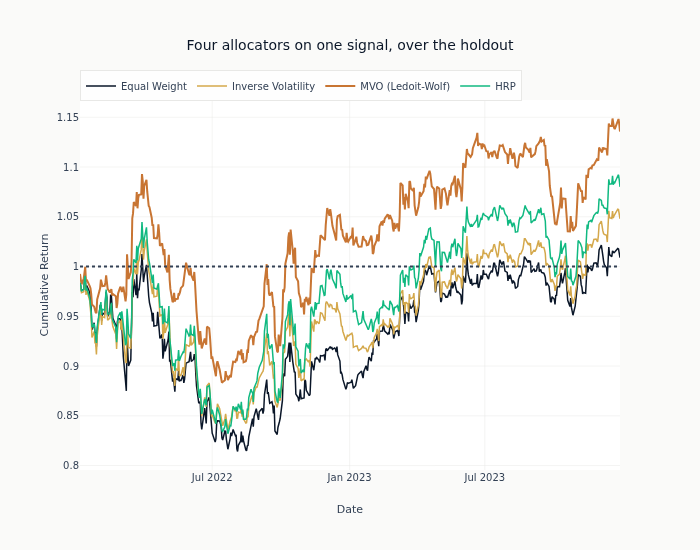

In [32]:
fig = go.Figure()

palette = ml4t_palette(4, categorical=True)
colors = dict(zip(allocation_methods, palette, strict=True))
holdout_leader = str(comparison_df.iloc[0]["Method"])

for name, result in results.items():
    fig.add_trace(
        go.Scatter(
            x=result["dates"],
            y=result["cumulative_return"],
            mode="lines",
            name=name,
            line=dict(color=colors[name], width=2 if name == selected_method else 1.5),
        )
    )

fig.add_hline(y=1.0, line_dash="dot", line_color=COLORS["neutral"])

fig.update_layout(
    title="Four allocators on one signal, over the holdout",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=550,
    legend=dict(orientation="h", x=0, y=1.08),
)
show_plotly_with_alt(
    fig,
    "Four cumulative return paths over the holdout, one per allocation method, with the allocator chosen before the holdout drawn thicker.",
)

**Finding**: Sustained curve separation, not short-lived spikes, is the evidence that one
allocator is adding value beyond noise in the shared signal.

## 9. Drawdown Analysis

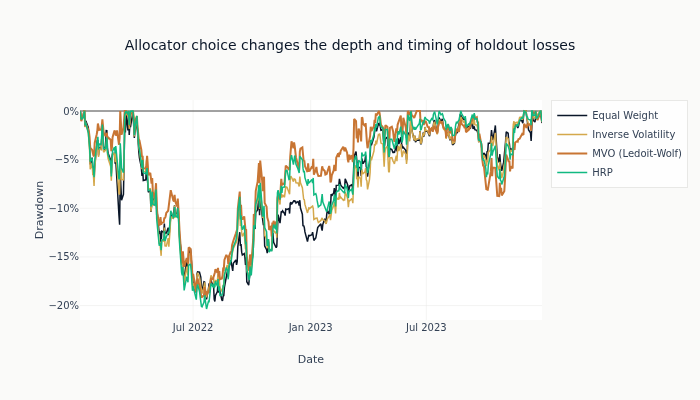

In [33]:
fig = go.Figure()

for name, result in results.items():
    dd = portfolio_analyses[name].compute_drawdown_analysis()
    fig.add_trace(
        go.Scatter(
            x=result["dates"],
            y=dd.underwater_curve.to_numpy(),
            mode="lines",
            name=name,
            line=dict(color=colors[name], width=2 if name == selected_method else 1.5),
        )
    )

fig.update_layout(
    title="Allocator choice changes the depth and timing of holdout losses",
    xaxis_title="Date",
    yaxis_title="Drawdown",
    height=400,
    yaxis_tickformat=".0%",
)
show_plotly_with_alt(
    fig,
    "Four underwater curves over the holdout, one per allocation method, all at or below zero.",
)

**Trading implication**: Lower and shallower drawdowns can dominate small Sharpe differences
when capital constraints are driven by investor risk tolerance.

## 10. Rolling Sharpe Ratio

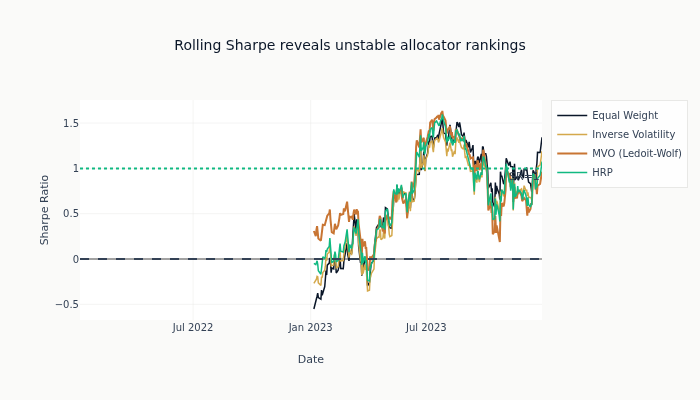

In [34]:
fig = go.Figure()

for name, result in results.items():
    rolling = portfolio_analyses[name].compute_rolling_metrics(
        windows=[252],
        metrics=["sharpe"],
    )
    rs_raw = np.asarray(rolling.sharpe[252].to_list(), dtype=float)
    rs = np.concatenate(([np.nan], rs_raw[:-1])) if rs_raw.size else rs_raw
    fig.add_trace(
        go.Scatter(
            x=result["dates"],
            y=rs,
            mode="lines",
            name=name,
            line=dict(color=colors[name], width=2 if name == selected_method else 1.5),
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.add_hline(
    y=1,
    line_dash="dot",
    line_color=COLORS["positive"],
    annotation_text="SR=1",
    annotation_position="bottom right",
)

fig.update_layout(
    title="Rolling Sharpe reveals unstable allocator rankings",
    xaxis_title="Date",
    yaxis_title="Sharpe Ratio",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Four rolling 252-day Sharpe ratios against date, crossing each other repeatedly, with reference lines at zero and one.",
)

**Finding**: Rolling Sharpe is a persistence diagnostic. It does not by itself define a regime
classifier or authorize switching allocators after observing the holdout.

### Predeclared Volatility-Regime Diagnostic

The regime threshold is the median trailing 63-day SPY volatility estimated only through the
selection region. Applying that frozen threshold to holdout dates describes performance across
lower- and higher-volatility observations without fitting a switching rule on the holdout.

In [35]:
spy_trailing_vol = returns["SPY"].rolling(63).std() * np.sqrt(252)
regime_threshold = float(spy_trailing_vol.loc[:SELECTION_END].dropna().median())
regime_rows = []
for name, result in results.items():
    result_returns = pd.Series(result["returns"], index=pd.to_datetime(result["dates"]))
    aligned_vol = spy_trailing_vol.reindex(result_returns.index)
    for regime, mask in {
        "Lower volatility": aligned_vol <= regime_threshold,
        "Higher volatility": aligned_vol > regime_threshold,
    }.items():
        sliced = result_returns.loc[mask.fillna(False)]
        sliced_sharpe = (
            float(sliced.mean() / sliced.std(ddof=1) * np.sqrt(252))
            if len(sliced) > 1 and sliced.std(ddof=1) > 0
            else np.nan
        )
        regime_rows.append(
            {
                "Method": name,
                "Regime": regime,
                "Observations": len(sliced),
                "Annualized Sharpe": sliced_sharpe,
            }
        )

regime_comparison = pl.DataFrame(regime_rows).sort(["Regime", "Annualized Sharpe"], descending=True)
display(
    Markdown(
        f"The frozen annualized-volatility threshold is **{regime_threshold:.1%}**. "
        "These slices are descriptive; no allocator is reselected from them."
    )
)
regime_comparison

The frozen annualized-volatility threshold is **12.1%**. These slices are descriptive; no allocator is reselected from them.

Method,Regime,Observations,Annualized Sharpe
str,str,i64,f64
"""Equal Weight""","""Lower volatility""",85,-0.653838
"""Inverse Volatility""","""Lower volatility""",85,-0.976304
"""HRP""","""Lower volatility""",85,-1.683887
"""MVO (Ledoit-Wolf)""","""Lower volatility""",85,-2.141925
"""MVO (Ledoit-Wolf)""","""Higher volatility""",414,0.879728
"""HRP""","""Higher volatility""",414,0.555509
"""Inverse Volatility""","""Higher volatility""",414,0.36326
"""Equal Weight""","""Higher volatility""",414,0.195427


For $T$ daily observations and $P=252$ periods per year, the standard error of an annualized
Sharpe ratio under the i.i.d. approximation is:

$$SE(\hat{SR}_{ann}) \approx \sqrt{\frac{P + \frac{\hat{SR}_{ann}^2}{2}}{T}}.$$

Serial dependence and allocator shopping require stronger inference than this IID scale check.

## 11. Relative Performance

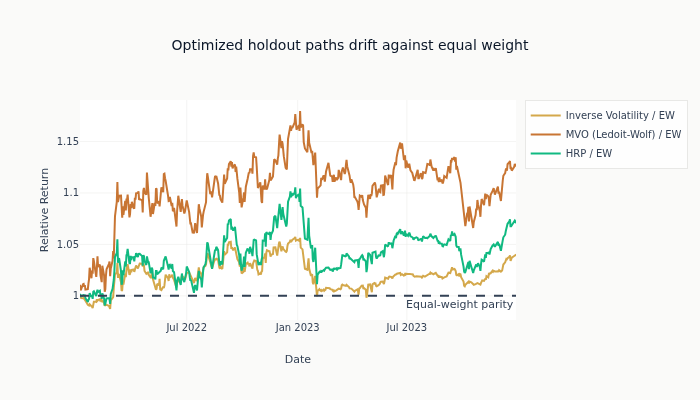

In [36]:
# Compute relative performance vs Equal Weight baseline
baseline_cum = results["Equal Weight"]["cumulative_return"]

fig = go.Figure()

for name, result in results.items():
    if name == "Equal Weight":
        continue

    # Align lengths
    min_len = min(len(result["cumulative_return"]), len(baseline_cum))
    relative = result["cumulative_return"][:min_len] / baseline_cum[:min_len]

    fig.add_trace(
        go.Scatter(
            x=result["dates"][:min_len],
            y=relative,
            mode="lines",
            name=f"{name} / EW",
            line=dict(color=colors[name], width=2),
        )
    )

fig.add_hline(
    y=1.0,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="Equal-weight parity",
    annotation_position="bottom right",
)

fig.update_layout(
    title="Optimized holdout paths drift against equal weight",
    xaxis_title="Date",
    yaxis_title="Relative Return",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Three ratio curves against date, each optimized allocation's cumulative return divided by equal weight's, with a dashed line at parity.",
)

**Trading implication**: Relative-performance drift below parity suggests keeping equal-weight
as the default fallback when optimization confidence degrades.

## 12. Reading the Comparison Table

The pre-holdout region makes the only selection decision. The holdout table then answers whether
that frozen choice generalizes. Its descriptive leader is reported for diagnosis but is never fed
back into the tear sheet or engine.

In [37]:
descriptive_leader = comparison_df.iloc[0]
selected_row = comparison_df.loc[comparison_df["Method"] == selected_method].iloc[0]
equal_row = comparison_df.loc[comparison_df["Method"] == "Equal Weight"].iloc[0]
selected_gap_vs_ew = float(selected_row["Sharpe Ratio"] - equal_row["Sharpe Ratio"])

print(f"Selected before the holdout: {selected_method}")
print(f"  its holdout Sharpe:            {selected_row['Sharpe Ratio']:.3f}")
print(f"  IID standard error:            {selected_row['Sharpe SE (IID)']:.3f}")
print(f"  gap against equal weight:      {selected_gap_vs_ew:+.3f}")
print(f"Highest holdout Sharpe:        {descriptive_leader['Method']}")

Selected before the holdout: MVO (Ledoit-Wolf)
  its holdout Sharpe:            0.507
  IID standard error:            0.711
  gap against equal weight:      +0.399
Highest holdout Sharpe:        MVO (Ledoit-Wolf)


### What this comparison produced

Four allocators, one signal, one holdout. The four rows differ only in how capital is spread
across the same selected ETFs on the same dates, so the spread between them is the allocation
decision and nothing else.

Read the Sharpe column against three things beside it. The IID standard error says how wide the
Sharpe estimate is on this many observations, and it is wide enough that most of the gaps in the
table sit inside it. The turnover column says what each allocator would have to trade to hold
its weights, and this table is gross of what that trading costs. The `Selected pre-holdout`
marker says which allocator was chosen before any of these numbers existed - the only decision
the notebook makes, and the only row whose holdout figure is not selected on.

The regime slice is descriptive in the same way. It splits the holdout at a volatility
threshold frozen before it, so the two Sharpe ratios per allocator describe conditional
behaviour; no allocator is re-chosen from them.

In [38]:
# Final descriptive holdout table, sorted for readability but not used for selection
final_summary = (
    comparison_df[
        ["Method", "Selected pre-holdout", "Sharpe Ratio", "Annual Return", "Max Drawdown"]
    ]
    .reset_index(drop=True)
    .rename_axis("Rank")
)
final_summary.index = final_summary.index + 1
final_summary.style.format(
    {"Sharpe Ratio": "{:.3f}", "Annual Return": "{:.1%}", "Max Drawdown": "{:.1%}"}
)

,Method,Selected pre-holdout,Sharpe Ratio,Annual Return,Max Drawdown
Rank,,,,,
1,MVO (Ledoit-Wolf),True,0.507,6.6%,-19.2%
2,HRP,False,0.323,4.0%,-20.4%
3,Inverse Volatility,False,0.227,2.4%,-19.2%
4,Equal Weight,False,0.108,0.4%,-19.6%


## 13. Holdout Tear Sheet for the Preselected Allocator - `ml4t-diagnostic`

`ml4t-diagnostic` packages the metrics + plots above into a reusable tear
sheet. We build it for the allocator selected on data through 2021, with SPY
as the benchmark so the alpha, beta, and information-ratio readouts have meaning.

The same `PortfolioTearSheet` object supports two delivery modes:

- **Inline** - `tear_sheet.show()` renders the metrics block plus each Plotly
  figure as standard cell outputs, useful for interactive analysis.
- **HTML** - `tear_sheet.save_html(path)` writes a self-contained file for
  sharing or archival; the same content, packaged for distribution.

Holdout tear sheet generated for preselected allocator: MVO (Ledoit-Wolf)


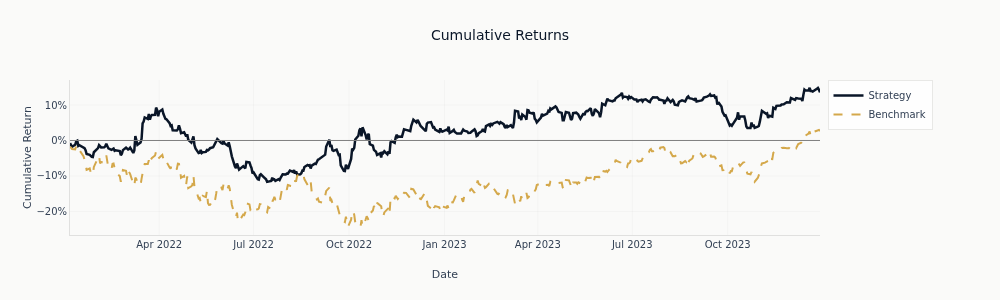

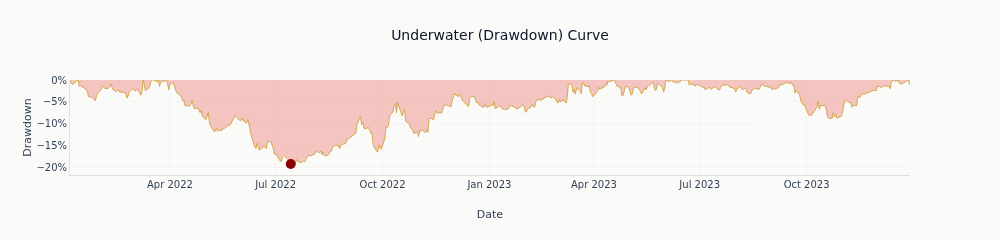

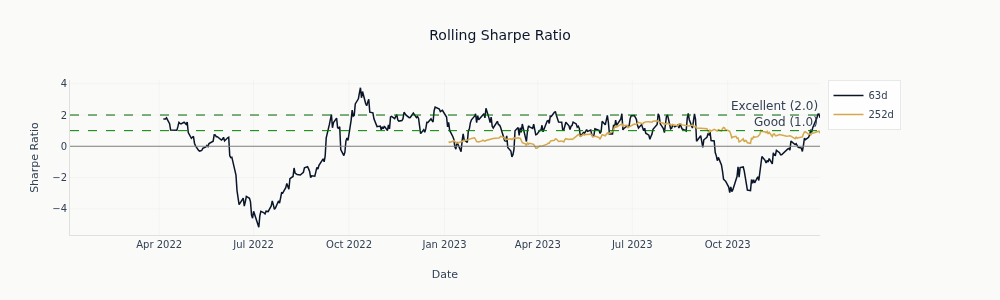

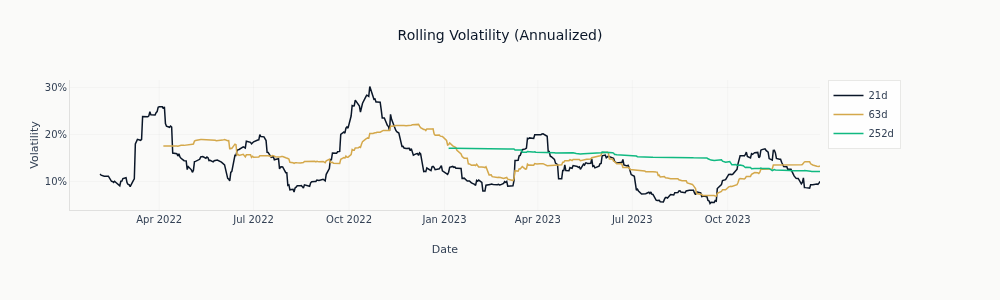

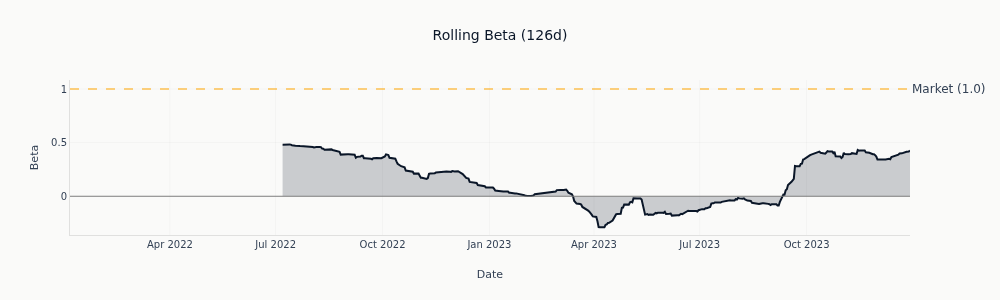

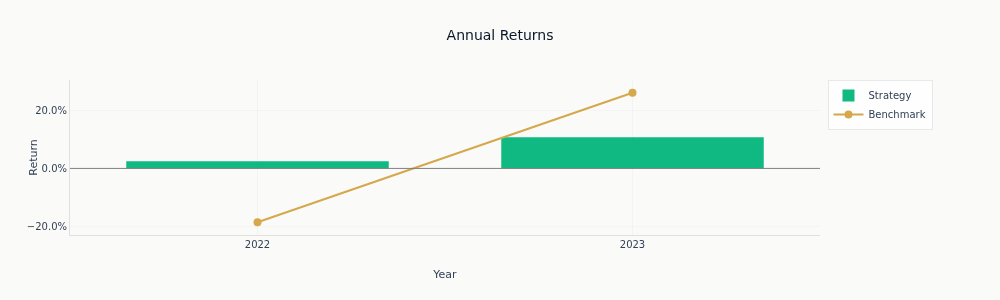

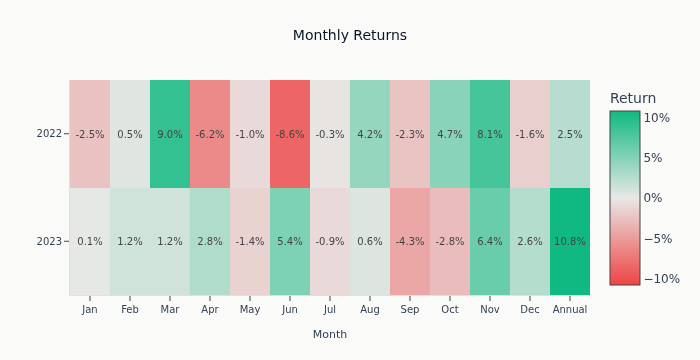

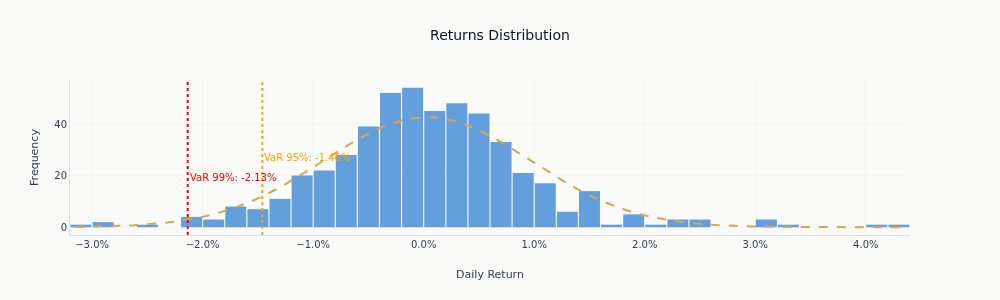

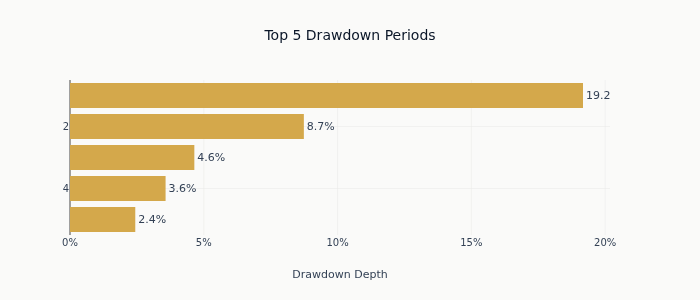

In [39]:
selected_result = results[selected_method]

# Align SPY benchmark to the selected allocator's holdout date index
spy_aligned = (
    pd.Series(returns["SPY"].values, index=returns.index)
    .reindex(pd.to_datetime(selected_result["dates"]))
    .dropna()
)
common_dates = pd.Index(selected_result["dates"]).intersection(spy_aligned.index)
selected_returns_aligned = pd.Series(
    selected_result["returns"], index=selected_result["dates"]
).loc[common_dates]
spy_aligned = spy_aligned.loc[common_dates]

selected_analysis = PortfolioAnalysis(
    returns=selected_returns_aligned.to_numpy(),
    benchmark=spy_aligned.to_numpy(),
    dates=common_dates,
    risk_free=0.0,
    periods_per_year=252,
)


def style_diagnostic_figures(figures: dict[str, go.Figure]) -> None:
    """Apply ML4T styling and readable legends to dashboard figures in place."""
    diverging = ml4t_diverging()
    legend_figures = {
        "Cumulative Returns",
        "Rolling Sharpe Ratio",
        "Rolling Volatility",
        "Annual Returns",
    }
    for figure_name, diagnostic_figure in figures.items():
        show_legend = figure_name in legend_figures
        bottom_margin = 90 if figure_name == "Rolling Volatility" else 65
        diagnostic_figure.update_layout(
            template="ml4t",
            paper_bgcolor=COLORS["bg_light"],
            plot_bgcolor=COLORS["bg_light"],
            font=dict(color=COLORS["neutral"]),
            margin=dict(l=70, r=180 if show_legend else 90, t=80, b=bottom_margin),
            showlegend=show_legend,
            legend=dict(x=1.01, xanchor="left", y=1.0, yanchor="top"),
        )
        if figure_name == "Rolling Volatility":
            diagnostic_figure.update_xaxes(title_text="Date", automargin=True)
        for trace in diagnostic_figure.data:
            if show_legend:
                trace.update(showlegend=True)
            if trace.type == "heatmap":
                trace.update(
                    colorscale=[
                        [0.0, diverging[0]],
                        [0.5, diverging[1]],
                        [1.0, diverging[2]],
                    ],
                    zmid=0,
                )


selected_tear_sheet = create_portfolio_dashboard(selected_analysis)
style_diagnostic_figures(selected_tear_sheet.figures)

print(f"Holdout tear sheet generated for preselected allocator: {selected_method}")

# Inline display: metrics summary + each constituent figure as a separate cell.
selected_tear_sheet.show()

In [40]:
# HTML delivery: same content packaged as a self-contained file.
output_dir = get_output_dir(17, "allocator_comparison")
output_dir.mkdir(parents=True, exist_ok=True)
selected_html_path = (
    output_dir
    / f"allocator_comparison_{selected_method.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')}_tear_sheet.html"
)
selected_tear_sheet.save_html(selected_html_path, include_plotlyjs="cdn")
print(f"Holdout tear sheet saved under the ML4T output directory: {selected_html_path.name}")
print(f"  Figures embedded: {list(selected_tear_sheet.figures.keys())}")

Holdout tear sheet saved under the ML4T output directory: allocator_comparison_mvo_ledoit_wolf_tear_sheet.html
  Figures embedded: ['Cumulative Returns', 'Drawdown', 'Rolling Sharpe Ratio', 'Rolling Volatility', 'Rolling Beta', 'Annual Returns', 'Monthly Returns Heatmap', 'Returns Distribution', 'Top Drawdowns']


## 14. Execution-Aware Holdout Replay with ml4t-backtest

The gross weight-based comparison isolates allocation effects. This replay sends the allocator
chosen before the holdout through actual canonical OHLCV bars with NEXT_BAR execution, commission,
and slippage. It does not use the descriptive holdout ranking to change the selected method.

The replay is an execution diagnostic rather than a claim that all four gross rankings survive
costs.

### Strategy Wrapper for ml4t-backtest

This class adapts the preselected allocator to the engine API.

In [41]:
def compute_target_weights(
    date_signals: pd.DataFrame,
    available_returns: pd.DataFrame,
    allocation_fn: Callable,
    allocation_name: str,
    allocation_window: int,
) -> dict[str, float]:
    """Build long/short target weights for one rebalance date."""
    target_weights: dict[str, float] = {}
    long_stocks = date_signals[date_signals["ml_signal"] > 0]["symbol"].tolist()
    short_stocks = date_signals[date_signals["ml_signal"] < 0]["symbol"].tolist()

    if long_stocks:
        if allocation_name == "Equal Weight":
            long_weights = equal_weight_allocation(long_stocks, len(long_stocks))
        else:
            long_weights = allocation_fn(available_returns, long_stocks, allocation_window)
        target_weights.update(long_weights)

    if short_stocks:
        if allocation_name == "Equal Weight":
            short_weights = equal_weight_allocation(short_stocks, len(short_stocks))
        else:
            short_weights = allocation_fn(available_returns, short_stocks, allocation_window)
        target_weights.update({k: -v for k, v in short_weights.items()})
    return target_weights

#### Engine Strategy Class

In [42]:
class AllocatorComparisonStrategy(Strategy):
    """Apply comparison allocations through ml4t-backtest execution."""

    def __init__(
        self,
        assets,
        signals_df,
        allocation_fn,
        allocation_name,
        returns_df,
        allocation_window,
    ):
        self.signals_df = signals_df
        self.allocation_fn = allocation_fn
        self.allocation_name = allocation_name
        self.returns_df = returns_df
        self.allocation_window = allocation_window
        self.signal_dates = set(signals_df["timestamp"].unique())
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.01,
                allow_fractional=False,
                allow_short=True,
            )
        )

    def on_data(self, timestamp, data, context, broker):
        current_date = timestamp.date() if hasattr(timestamp, "timestamp") else timestamp
        if current_date not in self.signal_dates:
            return
        date_signals = self.signals_df[self.signals_df["timestamp"] == current_date]
        if date_signals.empty:
            return
        target_weights = compute_target_weights(
            date_signals,
            self.returns_df.loc[:current_date],
            self.allocation_fn,
            self.allocation_name,
            self.allocation_window,
        )
        if not target_weights:
            return
        orders = self.executor.execute(target_weights, data, broker)
        if orders:
            print(f"[{current_date}] {self.allocation_name}: {len(orders)} orders")

In [43]:
# Prepare canonical OHLCV data for ml4t-backtest
first_engine_signal = pd.Timestamp(holdout_signals["timestamp"].min()).date()
prices_long = (
    etf_bars.filter(
        (pl.col("symbol").is_in(loaded_symbols))
        & (pl.col("timestamp") >= pl.lit(first_engine_signal))
    )
    .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    .sort(["timestamp", "symbol"])
)
vector_terminal_date = pd.Timestamp(returns.index.max()).date()
engine_terminal_date = pd.Timestamp(prices_long["timestamp"].max()).date()
if engine_terminal_date != vector_terminal_date:
    raise ValueError(
        f"Matched-horizon check failed: vector={vector_terminal_date}, engine={engine_terminal_date}"
    )
if sorted(prices_long["symbol"].unique().to_list()) != sorted(loaded_symbols):
    raise ValueError("Matched-universe check failed between vector and engine paths")
print(
    "Matched horizon and universe: "
    f"final_signal={pd.Timestamp(holdout_signals['timestamp'].max()).date()}, "
    f"terminal={vector_terminal_date}, assets={len(loaded_symbols)}"
)

bar_integrity = prices_long.select(
    (pl.col("open") == pl.col("close")).all().alias("all_open_equals_close"),
    (pl.col("high") == pl.col("close")).all().alias("all_high_equals_close"),
    (pl.col("low") == pl.col("close")).all().alias("all_low_equals_close"),
    pl.col("volume").n_unique().alias("unique_volume_values"),
).row(0, named=True)
if (
    bar_integrity["all_open_equals_close"]
    or bar_integrity["all_high_equals_close"]
    or bar_integrity["all_low_equals_close"]
    or bar_integrity["unique_volume_values"] <= 1
):
    raise ValueError(f"Engine feed failed canonical OHLCV integrity checks: {bar_integrity}")
print(f"Canonical OHLCV integrity: {bar_integrity}")

Matched horizon and universe: final_signal=2023-12-06, terminal=2023-12-29, assets=36
Canonical OHLCV integrity: {'all_open_equals_close': False, 'all_high_equals_close': False, 'all_low_equals_close': False, 'unique_volume_values': 17525}


In [44]:
# Create DataFeed
feed = DataFeed(prices_df=prices_long)

# Run the execution-aware backtest with the allocator frozen before the holdout
selected_fn = allocation_methods[selected_method]

print(f"\nRunning preselected {selected_method} through ml4t-backtest...")


Running preselected MVO (Ledoit-Wolf) through ml4t-backtest...


In [45]:
# Convert signal dates to proper format
signals_with_dates = holdout_signals.copy()
signals_with_dates["timestamp"] = signals_with_dates["timestamp"].apply(
    lambda x: pd.Timestamp(x).date()
)

strategy = AllocatorComparisonStrategy(
    assets=loaded_symbols,
    signals_df=signals_with_dates,
    allocation_fn=selected_fn,
    allocation_name=selected_method,
    returns_df=returns,
    allocation_window=ALLOCATION_WINDOW,
)

engine = Engine(
    feed=feed,
    strategy=strategy,
    config=BacktestConfig(
        initial_cash=100_000,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=COMMISSION_RATE,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=SLIPPAGE_RATE,
        allow_short_selling=True,
    ),
)

ml4t_results = engine.run()

[2022-01-04] MVO (Ledoit-Wolf): 6 orders
[2022-02-03] MVO (Ledoit-Wolf): 11 orders
[2022-03-07] MVO (Ledoit-Wolf): 16 orders
[2022-04-05] MVO (Ledoit-Wolf): 16 orders


[2022-05-05] MVO (Ledoit-Wolf): 13 orders


[2022-06-06] MVO (Ledoit-Wolf): 10 orders
[2022-07-07] MVO (Ledoit-Wolf): 16 orders
[2022-08-05] MVO (Ledoit-Wolf): 14 orders


[2022-09-06] MVO (Ledoit-Wolf): 13 orders
[2022-10-05] MVO (Ledoit-Wolf): 10 orders
[2022-11-03] MVO (Ledoit-Wolf): 11 orders
[2022-12-05] MVO (Ledoit-Wolf): 11 orders


[2023-01-05] MVO (Ledoit-Wolf): 12 orders


[2023-02-06] MVO (Ledoit-Wolf): 11 orders
[2023-03-08] MVO (Ledoit-Wolf): 12 orders
[2023-04-06] MVO (Ledoit-Wolf): 12 orders


[2023-05-08] MVO (Ledoit-Wolf): 14 orders
[2023-06-07] MVO (Ledoit-Wolf): 11 orders
[2023-07-10] MVO (Ledoit-Wolf): 8 orders
[2023-08-08] MVO (Ledoit-Wolf): 11 orders


[2023-09-07] MVO (Ledoit-Wolf): 12 orders


[2023-10-06] MVO (Ledoit-Wolf): 12 orders
[2023-11-06] MVO (Ledoit-Wolf): 11 orders
[2023-12-06] MVO (Ledoit-Wolf): 11 orders


In [46]:
print(f"Execution-aware holdout replay of {selected_method}:")
print(f"Final Value:     ${ml4t_results['final_value']:,.2f}")
print(f"Total Return:    {ml4t_results['total_return_pct']:.2f}%")
print(f"Sharpe Ratio:    {ml4t_results['sharpe']:.3f}")
print(f"Max Drawdown:    {ml4t_results['max_drawdown_pct']:.2f}%")
print(f"Order Fills:     {len(ml4t_results['fills'])}")
print(f"Round-Trips:     {ml4t_results['num_trades']}")
print(f"Total Commission: ${ml4t_results['total_commission']:,.2f}")
print(f"Total Slippage:   ${ml4t_results['total_slippage']:,.2f}")

# Compare with weight-based simulation
weight_result = results[selected_method]
print("\nComparison with Weight-Based Simulation:")
weight_total_return = float(weight_result["metrics"].get("total_return", 0.0))
print(f"  Weight-Based Return: {weight_total_return * 100:.2f}%")
print(f"  ml4t-backtest Return: {ml4t_results['total_return_pct']:.2f}%")
print(f"  Difference: {ml4t_results['total_return_pct'] - weight_total_return * 100:.2f}%")
print(
    "\nThe execution replay reports the combined effect of its configured costs and fill schedule;"
)
print("this notebook does not attribute the return difference to individual mechanisms.")

Execution-aware holdout replay of MVO (Ledoit-Wolf):
Final Value:     $99,369.94
Total Return:    -0.63%
Sharpe Ratio:    0.054
Max Drawdown:    19.97%
Order Fills:     283
Round-Trips:     149
Total Commission: $6,765.93
Total Slippage:   $3,382.97

Comparison with Weight-Based Simulation:
  Weight-Based Return: 13.56%
  ml4t-backtest Return: -0.63%
  Difference: -14.19%

The execution replay reports the combined effect of its configured costs and fill schedule;
this notebook does not attribute the return difference to individual mechanisms.


**Finding**: The execution replay is a diagnostic for the preselected allocator. Because the
engine applies its configured costs and fill schedule jointly, this notebook does not claim an
independent commission, slippage, or fill-timing attribution, nor does it rank all allocators
under execution costs.

### When to Use Each Approach

| Approach | Use Case |
|----------|----------|
| **Weight-Based Simulation** | Method selection, quick comparison, isolating allocation effects |
| **ml4t-backtest** | Execution cost modeling, fill diagnostics, strategy validation |

For the controlled comparison, weight-based simulation is appropriate because:
- All methods use identical execution assumptions
- We're isolating the allocation method's impact
- It's faster for comparing multiple methods

For execution-aware validation, use ml4t-backtest because:
- Bar-based execution modeling on actual OHLCV
- Commission and slippage impact
- Position tracking and risk management
- A path toward live-system integration

## Key Takeaways

1. **The same signal allocated four ways gives four results.** Selection decides what is held
   and allocation decides how much of each, and the second is not a detail: the spread across
   these four rows comes entirely from it.
2. **The allocators that estimate a covariance pay for the estimate.** Minimum variance and
   HRP both read the second moment; equal weight and inverse volatility read little or none of
   it. Whether the estimate earns its error depends on the universe width and the sample, which
   is why the ordering here is a fact about this run rather than a ranking of methods.
3. **Select once, before the evaluation window opens.** The pre-holdout region makes the choice
   and the holdout describes what that choice went on to do. Reading the holdout table and then
   picking the top row would turn the holdout into a second selection window, and there would be
   nothing left to test the choice against.
4. **The standard error in the table bounds one estimate, not a comparison.** It says how
   precisely each allocator's own Sharpe ratio is measured on this many observations, and it
   does not say whether two of them differ. The uncertainty of a gap is
   $\text{Var}(S_1) + \text{Var}(S_2) - 2\,\text{Cov}(S_1, S_2)$, and these four allocators
   hold the same assets on the same dates from one signal, so that covariance term is not
   zero and the gap's uncertainty is not read off the two levels. Measuring it takes a paired
   block bootstrap: resample blocks of dates, recompute both Sharpe ratios on the same
   resampled dates, and read the distribution of their difference. Blocks rather than single
   days, because daily returns are serially dependent and the IID formula in the table does
   not carry that.
5. **Turnover is the part of an allocator's cost the gross table hides.** A method that improves
   Sharpe while trading twice as much has not been shown to be better until the trading is
   priced, which Chapter 18 does.

### Known limitations

- One universe, one signal, one selection region and one holdout. A different split date would
  refit the signal and could change which allocator is selected.
- The four-way table is gross of commission and slippage. Only the preselected allocator is
  replayed through the execution engine, and that replay applies costs and next-bar fills
  together, so it does not separate the two.
- The universe is a fixed list of funds that exist today, applied backwards over the sample.

**Next**: [`11_dl_portfolio_allocation`](11_dl_portfolio_allocation.ipynb) replaces the
allocation rule with a network that learns the weights directly from the return series.